In [25]:
import math
import torch
from torch.utils.data import TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import copy
import os
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.manual_seed(1)

Using device: cuda


In [ ]:
# Heston Monte Carlo pricer
@torch.no_grad()
def heston_mc_price_batch(
    X,
    n_paths=20000,
    n_steps=100,
    device=device,
    dtype=torch.float32
):
    X = X.to(device=device, dtype=dtype)

    S0    = X[:, 0]  # (B,)
    Y0    = X[:, 1]
    kappa = X[:, 2]
    mu    = X[:, 3]
    sigma = X[:, 4]
    r     = X[:, 5]
    rho   = X[:, 6]
    K     = X[:, 7]
    T     = X[:, 8]

    B = X.shape[0]

    # Expand to (B, n_paths)
    S = S0[:, None].repeat(1, n_paths)
    Y = Y0[:, None].repeat(1, n_paths)

    # Time step can differ across contracts because T differs
    dt = (T / n_steps)[:, None]
    sqrt_dt = torch.sqrt(dt)   

    rho_ = rho[:, None]        
    r_ = r[:, None]
    kappa_ = kappa[:, None]
    mu_ = mu[:, None]
    sigma_ = sigma[:, None]

    for _ in range(n_steps):
        Z1 = torch.randn(B, n_paths, device=device, dtype=dtype)
        Z2 = torch.randn(B, n_paths, device=device, dtype=dtype)
        W2 = rho_ * Z1 + torch.sqrt(1.0 - rho_ ** 2) * Z2

        Y_pos = torch.clamp(Y, min=0.0)
        Y = Y + kappa_ * (mu_ - Y_pos) * dt + sigma_ * torch.sqrt(Y_pos) * sqrt_dt * W2
        S = S * torch.exp((r_ - 0.5 * Y_pos) * dt + torch.sqrt(Y_pos) * sqrt_dt * Z1)

    payoff = torch.clamp(S - K[:, None], min=0.0)
    price = torch.exp(-r * T) * payoff.mean(dim=1)  # (B,)

    return price


@torch.no_grad()
def heston_mc_price_batch_av(
    X,
    n_paths=20000,
    n_steps=100,
    device=device,
    dtype=torch.float32
):
    """
    Heston Monte Carlo pricer with antithetic variates.
    """

    X = X.to(device=device, dtype=dtype)

    S0    = X[:, 0]
    Y0    = X[:, 1]
    kappa = X[:, 2]
    mu    = X[:, 3]
    sigma = X[:, 4]
    r     = X[:, 5]
    rho   = X[:, 6]
    K     = X[:, 7]
    T     = X[:, 8]

    B = X.shape[0]

    # make n_paths even
    if n_paths % 2 != 0:
        n_paths += 1

    half_paths = n_paths // 2

    S = S0[:, None].repeat(1, n_paths)
    Y = Y0[:, None].repeat(1, n_paths)

    dt = (T / n_steps)[:, None]
    sqrt_dt = torch.sqrt(dt)

    rho_ = rho[:, None]
    r_ = r[:, None]
    kappa_ = kappa[:, None]
    mu_ = mu[:, None]
    sigma_ = sigma[:, None]

    for _ in range(n_steps):
        Z1_half = torch.randn(B, half_paths, device=device, dtype=dtype)
        Z2_half = torch.randn(B, half_paths, device=device, dtype=dtype)

        Z1 = torch.cat([Z1_half, -Z1_half], dim=1)
        Z2 = torch.cat([Z2_half, -Z2_half], dim=1)

        W2 = rho_ * Z1 + torch.sqrt(1.0 - rho_ ** 2) * Z2

        Y_pos = torch.clamp(Y, min=0.0)

        Y = Y + kappa_ * (mu_ - Y_pos) * dt + sigma_ * torch.sqrt(Y_pos) * sqrt_dt * W2
        S = S * torch.exp((r_ - 0.5 * Y_pos) * dt + torch.sqrt(Y_pos) * sqrt_dt * Z1)

    payoff = torch.clamp(S - K[:, None], min=0.0)
    price = torch.exp(-r * T) * payoff.mean(dim=1)

    return price

In [14]:
drive.mount('/content/drive')

#data = torch.load("/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_raw_dataset.pt")
data = torch.load("/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_av_raw_dataset.pt")

X_train = data["X_train"].float()
y_train = data["y_train"].float()
X_test = data["X_test"].float()
y_test = data["y_test"].float()

mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True).clamp_min(1e-8)

X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2.a

In [ ]:
# True Heston parameters
S0_star = 100.0
Y0_star = 0.04
kappa_star = 3.0
mu_star = 0.04
sigma_star = 0.4
r_star = 0.02
rho_star = -0.7

print("Feller lhs =", 2 * kappa_star * mu_star)
print("sigma^2    =", sigma_star ** 2)

# Grid of maturities and strikes
T_grid = torch.tensor([0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00], dtype=torch.float32)
K_grid = torch.arange(60.0, 145.0, 5.0, dtype=torch.float32)
N = len(T_grid)
M = len(K_grid)
print("Number of maturities:", N)
print("Number of strikes   :", M)


def build_surface_inputs(S0, Y0, kappa, mu, sigma, r, rho, K_grid, T_grid, device=device):
    rows = []

    for T in T_grid:
        for K in K_grid:
            rows.append([
                S0,
                Y0,
                kappa,
                mu,
                sigma,
                r,
                rho,
                float(K.item()),
                float(T.item())
            ])

    X_surface = torch.tensor(rows, dtype=torch.float32, device=device)
    return X_surface


X_surface = build_surface_inputs(
    S0=S0_star,
    Y0=Y0_star,
    kappa=kappa_star,
    mu=mu_star,
    sigma=sigma_star,
    r=r_star,
    rho=rho_star,
    K_grid=K_grid,
    T_grid=T_grid,
    device=device
)

print("Surface input shape:", X_surface.shape)

# Price the whole grid with Monte Carlo
MC_PATHS_SURFACE = 200_000
N_STEPS_SURFACE = 1000

P_surface_vec = heston_mc_price_batch_av(
    X_surface,
    n_paths=MC_PATHS_SURFACE,
    n_steps=N_STEPS_SURFACE,
    device=device
)

P_surface = P_surface_vec.view(N, M).detach().cpu().numpy()
print("Surface shape:", P_surface.shape)

Feller lhs = 0.24
sigma^2    = 0.16000000000000003
Number of maturities: 8
Number of strikes   : 17
Surface input shape: torch.Size([136, 9])
Surface shape: (8, 17)


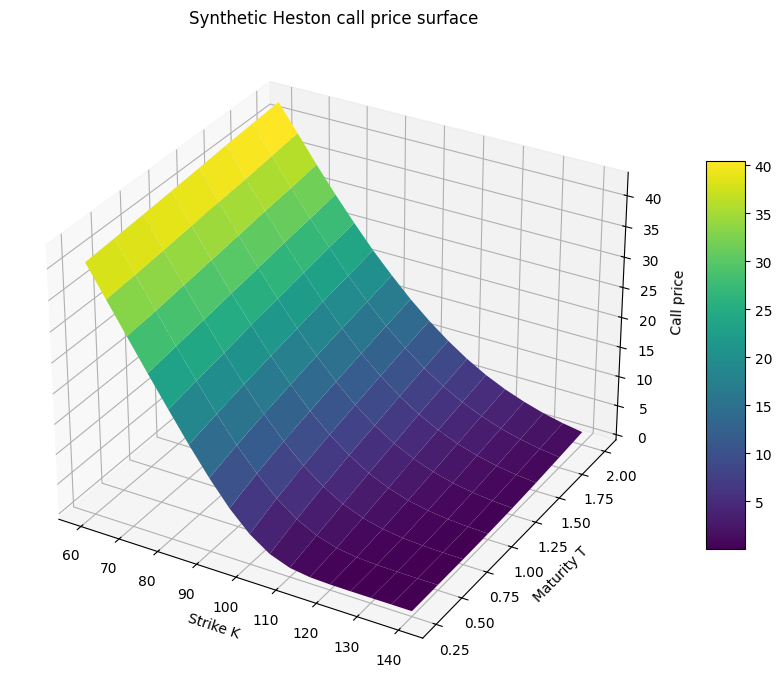

In [57]:
# 3D surface plot
K_mesh, T_mesh = np.meshgrid(K_grid.cpu().numpy(), T_grid.cpu().numpy())

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(K_mesh, T_mesh, P_surface, cmap='viridis', edgecolor='none')

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("Call price")
ax.set_title("Synthetic Heston call price surface")

fig.colorbar(surf, shrink=0.6, aspect=10)
plt.tight_layout()
plt.show()

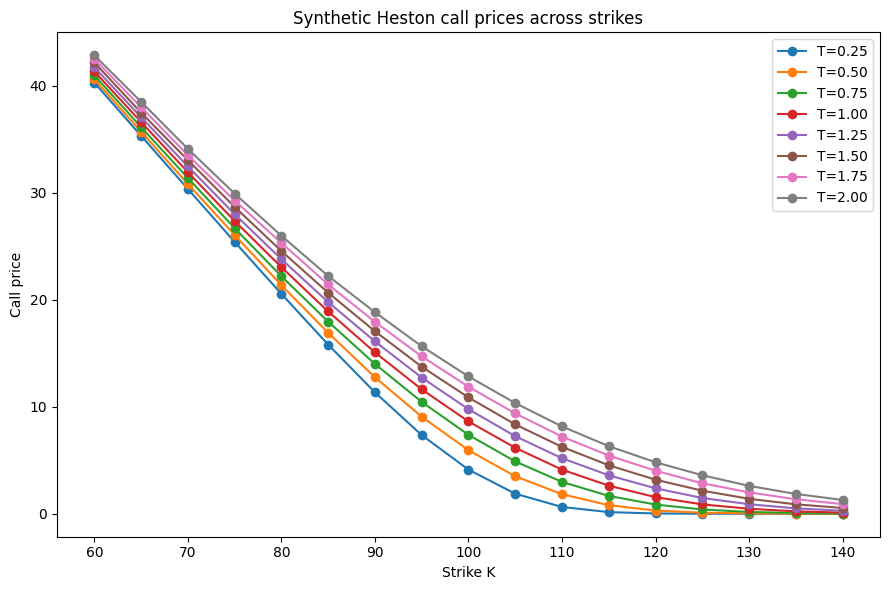

In [ ]:
plt.figure(figsize=(9, 6))

for i, T in enumerate(T_grid.cpu().numpy()):
    plt.plot(K_grid.cpu().numpy(), P_surface[i], marker='o', label=f"T={T:.2f}")
plt.xlabel("Strike K")
plt.ylabel("Call price")
plt.title("Synthetic Heston call prices across strikes")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
surface_data = {
    "true_params": {
        "S0": S0_star,
        "Y0": Y0_star,
        "kappa": kappa_star,
        "mu": mu_star,
        "sigma": sigma_star,
        "r": r_star,
        "rho": rho_star,
    },
    "K_grid": K_grid.cpu(),
    "T_grid": T_grid.cpu(),
    "P_surface": torch.tensor(P_surface),
    "X_surface": X_surface.detach().cpu(),
    "mc_paths": MC_PATHS_SURFACE,
    "n_steps": N_STEPS_SURFACE,
}

drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/exam_deep_learning/heston_exam_data"
os.makedirs(save_dir, exist_ok=True)

torch.save(
    surface_data,
    "/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_observed_surface.pt"
)

print("Synthetic observed surface saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Synthetic observed surface saved.


# 2.b

In [ ]:
class HestonMLPLarge(nn.Module):
    def __init__(self, input_dim=9, dropout=0.05):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.drop3 = nn.Dropout(dropout)

        self.fc4 = nn.Linear(256, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.drop4 = nn.Dropout(dropout)

        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.drop5 = nn.Dropout(dropout)

        self.fc6 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)
        self.drop6 = nn.Dropout(dropout)

        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.drop3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.drop4(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = F.relu(x)
        x = self.drop5(x)

        x = self.fc6(x)
        x = self.bn6(x)
        x = F.relu(x)
        x = self.drop6(x)

        x = self.out(x)
        return x


model_large = HestonMLPLarge(input_dim=9, dropout=0.05).to(device)
print(model_large)

model_ckpt_path = "/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_mlp_model_large.pt"
ckpt = torch.load(model_ckpt_path, map_location=device)
model = HestonMLPLarge(input_dim=9, dropout=0.05).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
# freeze NN weights: we optimize only the Heston parameters
for p in model.parameters():
    p.requires_grad = False

x_mean = ckpt["x_mean"].to(device).float()
x_std = ckpt["x_std"].to(device).float().clamp_min(1e-8)
print("Loaded trained surrogate model.")


surface_path = "/content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_observed_surface.pt"
surface_data = torch.load(surface_path, map_location=device)
K_grid = surface_data["K_grid"].to(device).float()
T_grid = surface_data["T_grid"].to(device).float()
P_surface_obs = surface_data["P_surface"].to(device).float()   # shape (N, M)

true_params = surface_data["true_params"]
S0_star = float(true_params["S0"])
Y0_star = float(true_params["Y0"])

print("Loaded synthetic observed surface.")
print("K_grid shape:", K_grid.shape)
print("T_grid shape:", T_grid.shape)
print("Known initial conditions: S0* =", S0_star, ", Y0* =", Y0_star)

HestonMLPLarge(
  (fc1): Linear(in_features=9, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.05, inplace=False)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.05, inplace=False)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.05, inplace=False)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop4): Dropout(p=0.05, inplace=False)
  (fc5): Linear(in_features=256, out_features=128, bias=True)
  (bn5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop5): Dropout(p=0.05, inplace=False)
  (fc6): Linear(

In [61]:
def build_surface_inputs_from_params(S0, Y0, kappa, mu, sigma, r, rho, K_grid, T_grid):
    TT, KK = torch.meshgrid(T_grid, K_grid, indexing="ij")
    ones = torch.ones_like(TT)

    X = torch.stack([
        S0 * ones,
        Y0 * ones,
        kappa * ones,
        mu * ones,
        sigma * ones,
        r * ones,
        rho * ones,
        KK,
        TT
    ], dim=-1)

    return X.view(-1, 9)

PARAM_BOUNDS = {
    "kappa": (0.5, 5.0),
    "mu":    (0.01, 0.25),
    "sigma": (0.1, 1.0),
    "r":     (0.0, 0.1),
    "rho":   (-0.95, 0.0),
}

def bounded_sigmoid(z, low, high):
    return low + (high - low) * torch.sigmoid(z)

def transform_raw_to_heston_params(raw):
    kappa = bounded_sigmoid(raw[0], *PARAM_BOUNDS["kappa"])
    mu    = bounded_sigmoid(raw[1], *PARAM_BOUNDS["mu"])
    sigma = bounded_sigmoid(raw[2], *PARAM_BOUNDS["sigma"])
    r     = bounded_sigmoid(raw[3], *PARAM_BOUNDS["r"])
    rho   = bounded_sigmoid(raw[4], *PARAM_BOUNDS["rho"])
    return kappa, mu, sigma, r, rho

def inverse_bounded_sigmoid(value, low, high, eps=1e-8):
    y = (value - low) / (high - low)
    y = np.clip(y, eps, 1 - eps)
    return np.log(y / (1 - y))


# CALIBRATION OBJECTIVE
def calibration_loss(raw_params, model, x_mean, x_std, S0_star, Y0_star, K_grid, T_grid, P_surface_obs):
    kappa, mu, sigma, r, rho = transform_raw_to_heston_params(raw_params)

    X_surface = build_surface_inputs_from_params(
        S0=torch.tensor(S0_star, device=device),
        Y0=torch.tensor(Y0_star, device=device),
        kappa=kappa,
        mu=mu,
        sigma=sigma,
        r=r,
        rho=rho,
        K_grid=K_grid,
        T_grid=T_grid
    )

    X_surface_std = (X_surface - x_mean) / x_std
    P_pred = model(X_surface_std).view_as(P_surface_obs)

    loss = torch.mean((P_pred - P_surface_obs) ** 2)
    return loss, P_pred, (kappa, mu, sigma, r, rho)

In [ ]:
def sample_random_init_guess():
    guess = {}
    for name, (low, high) in PARAM_BOUNDS.items():
        guess[name] = np.random.uniform(low, high)
    return guess

def init_raw_params_from_guess(guess, device=device):
    raw = torch.empty(5, device=device)
    raw[0] = torch.tensor(inverse_bounded_sigmoid(guess["kappa"], *PARAM_BOUNDS["kappa"]), device=device)
    raw[1] = torch.tensor(inverse_bounded_sigmoid(guess["mu"],    *PARAM_BOUNDS["mu"]), device=device)
    raw[2] = torch.tensor(inverse_bounded_sigmoid(guess["sigma"], *PARAM_BOUNDS["sigma"]), device=device)
    raw[3] = torch.tensor(inverse_bounded_sigmoid(guess["r"],     *PARAM_BOUNDS["r"]), device=device)
    raw[4] = torch.tensor(inverse_bounded_sigmoid(guess["rho"],   *PARAM_BOUNDS["rho"]), device=device)
    return nn.Parameter(raw)


def run_single_calibration(
    model,
    x_mean,
    x_std,
    S0_star,
    Y0_star,
    K_grid,
    T_grid,
    P_surface_obs,
    init_guess,
    n_iters=3000,
    lr=5e-3,
    grad_clip=1.0,
    verbose_every=250,
):
    raw_params = init_raw_params_from_guess(init_guess, device=device)
    optimizer = torch.optim.Adam([raw_params], lr=lr)

    loss_history = []
    param_history = []

    best_loss = float("inf")
    best_state = None

    for it in range(1, n_iters + 1):
        optimizer.zero_grad()

        loss, P_pred, params_tuple = calibration_loss(
            raw_params=raw_params,
            model=model,
            x_mean=x_mean,
            x_std=x_std,
            S0_star=S0_star,
            Y0_star=Y0_star,
            K_grid=K_grid,
            T_grid=T_grid,
            P_surface_obs=P_surface_obs
        )

        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_([raw_params], grad_clip)
        optimizer.step()

        kappa_hat, mu_hat, sigma_hat, r_hat, rho_hat = [p.item() for p in params_tuple]

        loss_history.append(loss.item())
        param_history.append([kappa_hat, mu_hat, sigma_hat, r_hat, rho_hat])

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = {
                "raw_params": raw_params.detach().clone(),
                "kappa": kappa_hat,
                "mu": mu_hat,
                "sigma": sigma_hat,
                "r": r_hat,
                "rho": rho_hat,
                "P_pred": P_pred.detach().clone(),
                "iter": it
            }

        if verbose_every is not None and (it % verbose_every == 0 or it == 1):
            print(
                f"Iter {it:4d} | loss={loss.item():.8f} | "
                f"kappa={kappa_hat:.4f}, mu={mu_hat:.4f}, sigma={sigma_hat:.4f}, "
                f"r={r_hat:.4f}, rho={rho_hat:.4f}"
            )

    result = {
        "init_guess": init_guess,
        "best_loss": best_loss,
        "best_state": best_state,
        "loss_history": loss_history,
        "param_history": np.array(param_history),
    }
    return result


def run_multistart_calibration(
    n_starts=20,
    n_iters=3000,
    lr=5e-3,
    grad_clip=1.0,
    verbose_every=250,
):
    all_runs = []
    global_best_loss = float("inf")
    global_best_run = None

    for s in range(1, n_starts + 1):
        print("=" * 80)
        print(f"START {s}/{n_starts}")

        init_guess = sample_random_init_guess()
        print("Initial guess:", init_guess)

        run = run_single_calibration(
            model=model,
            x_mean=x_mean,
            x_std=x_std,
            S0_star=S0_star,
            Y0_star=Y0_star,
            K_grid=K_grid,
            T_grid=T_grid,
            P_surface_obs=P_surface_obs,
            init_guess=init_guess,
            n_iters=n_iters,
            lr=lr,
            grad_clip=grad_clip,
            verbose_every=verbose_every,
        )

        all_runs.append(run)

        if run["best_loss"] < global_best_loss:
            global_best_loss = run["best_loss"]
            global_best_run = copy.deepcopy(run)

        print(f"Best loss for start {s}: {run['best_loss']:.10f}")

    return all_runs, global_best_run


all_runs, best_run = run_multistart_calibration(
    n_starts=10,
    n_iters=6000,
    lr=5e-3,
    grad_clip=1.0,
    verbose_every=500,
)

print("\nGLOBAL BEST LOSS:", best_run["best_loss"])


# best paarameters
best_state = best_run["best_state"]
kappa_cal = best_state["kappa"]
mu_cal    = best_state["mu"]
sigma_cal = best_state["sigma"]
r_cal     = best_state["r"]
rho_cal   = best_state["rho"]
P_surface_cal = best_state["P_pred"].detach().cpu().numpy()
P_surface_obs_np = P_surface_obs.detach().cpu().numpy()

print("\nTrue parameters vs calibrated parameters")
print(f"kappa: true = {true_params['kappa']:.6f}, calibrated = {kappa_cal:.6f}")
print(f"mu   : true = {true_params['mu']:.6f}, calibrated = {mu_cal:.6f}")
print(f"sigma: true = {true_params['sigma']:.6f}, calibrated = {sigma_cal:.6f}")
print(f"r    : true = {true_params['r']:.6f}, calibrated = {r_cal:.6f}")
print(f"rho  : true = {true_params['rho']:.6f}, calibrated = {rho_cal:.6f}")

START 1/10
Initial guess: {'kappa': 3.5981020158837276, 'mu': 0.13452982065620994, 'sigma': 0.958575877733588, 'r': 0.04383167146144933, 'rho': -0.5555822599290083}
Iter    1 | loss=28.23599434 | kappa=3.5981, mu=0.1345, sigma=0.9586, r=0.0438, rho=-0.5556
Iter  500 | loss=0.04277387 | kappa=2.5501, mu=0.0558, sigma=0.9548, r=0.0113, rho=-0.5053
Iter 1000 | loss=0.03500570 | kappa=2.6925, mu=0.0544, sigma=0.8471, r=0.0115, rho=-0.5570
Iter 1500 | loss=0.02908111 | kappa=2.4205, mu=0.0522, sigma=0.6814, r=0.0127, rho=-0.6100
Iter 2000 | loss=0.02775904 | kappa=2.2735, mu=0.0504, sigma=0.6112, r=0.0137, rho=-0.6243
Iter 2500 | loss=0.02753882 | kappa=2.2050, mu=0.0500, sigma=0.5867, r=0.0141, rho=-0.6317
Iter 3000 | loss=0.02753671 | kappa=2.2051, mu=0.0499, sigma=0.5863, r=0.0142, rho=-0.6303
Iter 3500 | loss=0.02753668 | kappa=2.2050, mu=0.0499, sigma=0.5862, r=0.0142, rho=-0.6302
Iter 4000 | loss=0.02753667 | kappa=2.2050, mu=0.0499, sigma=0.5863, r=0.0142, rho=-0.6302
Iter 4500 | los

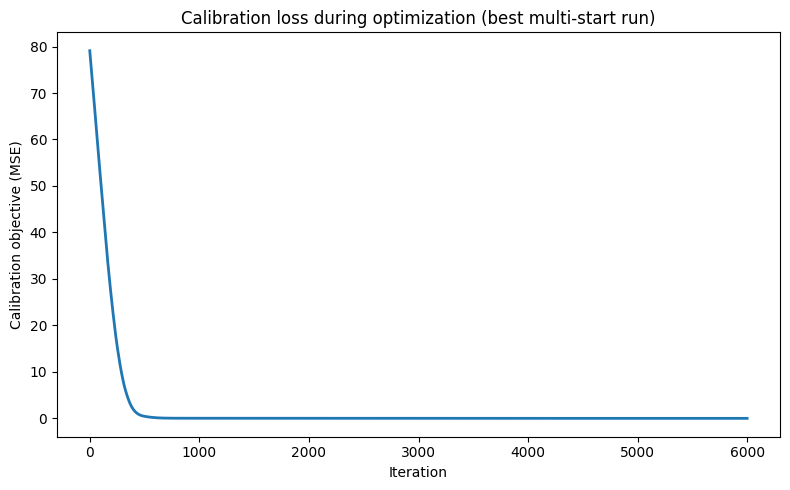

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(best_run["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Calibration objective (MSE)")
plt.title("Calibration loss during optimization (best multi-start run)")
plt.tight_layout()
plt.show()

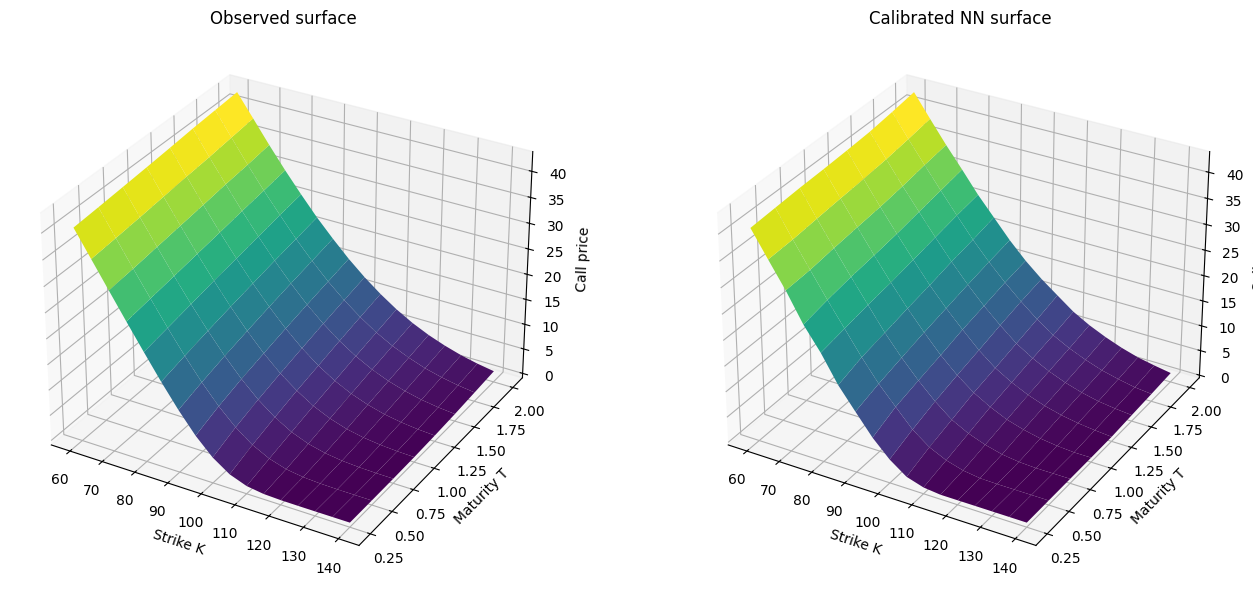

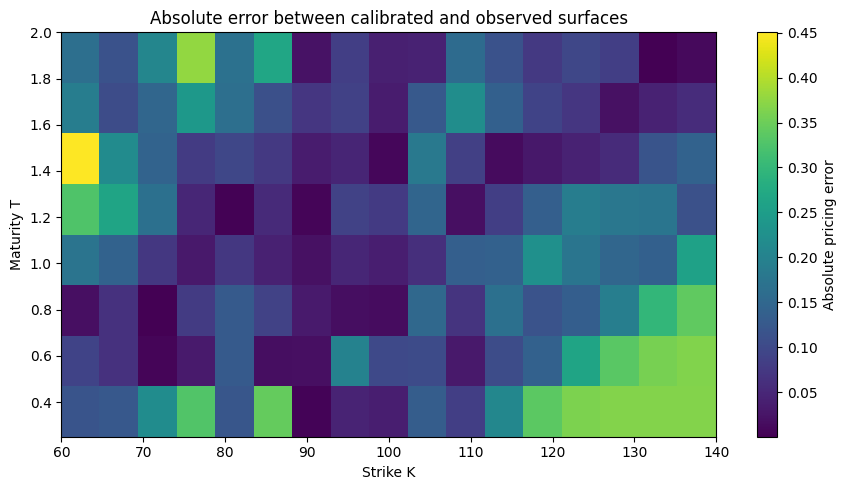


Calibration fit metrics on the observed surface:
Surface MAE       : 0.12953866
Surface RMSE      : 0.16510957
Surface Rel. Error: 50.65838623


In [ ]:
K_mesh, T_mesh = np.meshgrid(K_grid.detach().cpu().numpy(), T_grid.detach().cpu().numpy())

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(K_mesh, T_mesh, P_surface_obs_np, cmap='viridis', edgecolor='none')
ax1.set_title("Observed surface")
ax1.set_xlabel("Strike K")
ax1.set_ylabel("Maturity T")
ax1.set_zlabel("Call price")

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(K_mesh, T_mesh, P_surface_cal, cmap='viridis', edgecolor='none')
ax2.set_title("Calibrated NN surface")
ax2.set_xlabel("Strike K")
ax2.set_ylabel("Maturity T")
ax2.set_zlabel("Call price")

plt.tight_layout()
plt.show()


surface_abs_err = np.abs(P_surface_cal - P_surface_obs_np)

plt.figure(figsize=(9, 5))
im = plt.imshow(
    surface_abs_err,
    aspect='auto',
    origin='lower',
    extent=[K_grid.min().item(), K_grid.max().item(), T_grid.min().item(), T_grid.max().item()]
)
plt.colorbar(im, label="Absolute pricing error")
plt.xlabel("Strike K")
plt.ylabel("Maturity T")
plt.title("Absolute error between calibrated and observed surfaces")
plt.tight_layout()
plt.show()


abs_err_surface = np.abs(P_surface_cal - P_surface_obs_np)
rel_err_surface = abs_err_surface / (np.abs(P_surface_obs_np) + 1e-4)

print("\nCalibration fit metrics on the observed surface:")
print(f"Surface MAE       : {abs_err_surface.mean():.8f}")
print(f"Surface RMSE      : {np.sqrt(((P_surface_cal - P_surface_obs_np) ** 2).mean()):.8f}")
print(f"Surface Rel. Error: {rel_err_surface.mean():.8f}")

# 2.c)

In [ ]:
true_dict = {
    "kappa": true_params["kappa"],
    "mu": true_params["mu"],
    "sigma": true_params["sigma"],
    "r": true_params["r"],
    "rho": true_params["rho"],
}

calib_dict = {
    "kappa": kappa_cal,
    "mu": mu_cal,
    "sigma": sigma_cal,
    "r": r_cal,
    "rho": rho_cal,
}

rows = []
for key in true_dict:
    true_val = true_dict[key]
    calib_val = calib_dict[key]

    abs_err = abs(calib_val - true_val)
    rel_err = abs_err / (abs(true_val) + 1e-12)

    rows.append({
        "Parameter": key,
        "True": true_val,
        "Calibrated": calib_val,
        "Abs Error": abs_err,
        "Rel Error": rel_err
    })

df_params = pd.DataFrame(rows)
df_params = df_params.round(6)
print(df_params)

  Parameter  True  Calibrated  Abs Error  Rel Error
0     kappa  3.00    1.902148   1.097852   0.365951
1        mu  0.04    0.050246   0.010246   0.256144
2     sigma  0.40    0.555003   0.155003   0.387508
3         r  0.02    0.014146   0.005854   0.292694
4       rho -0.70   -0.618420   0.081580   0.116542


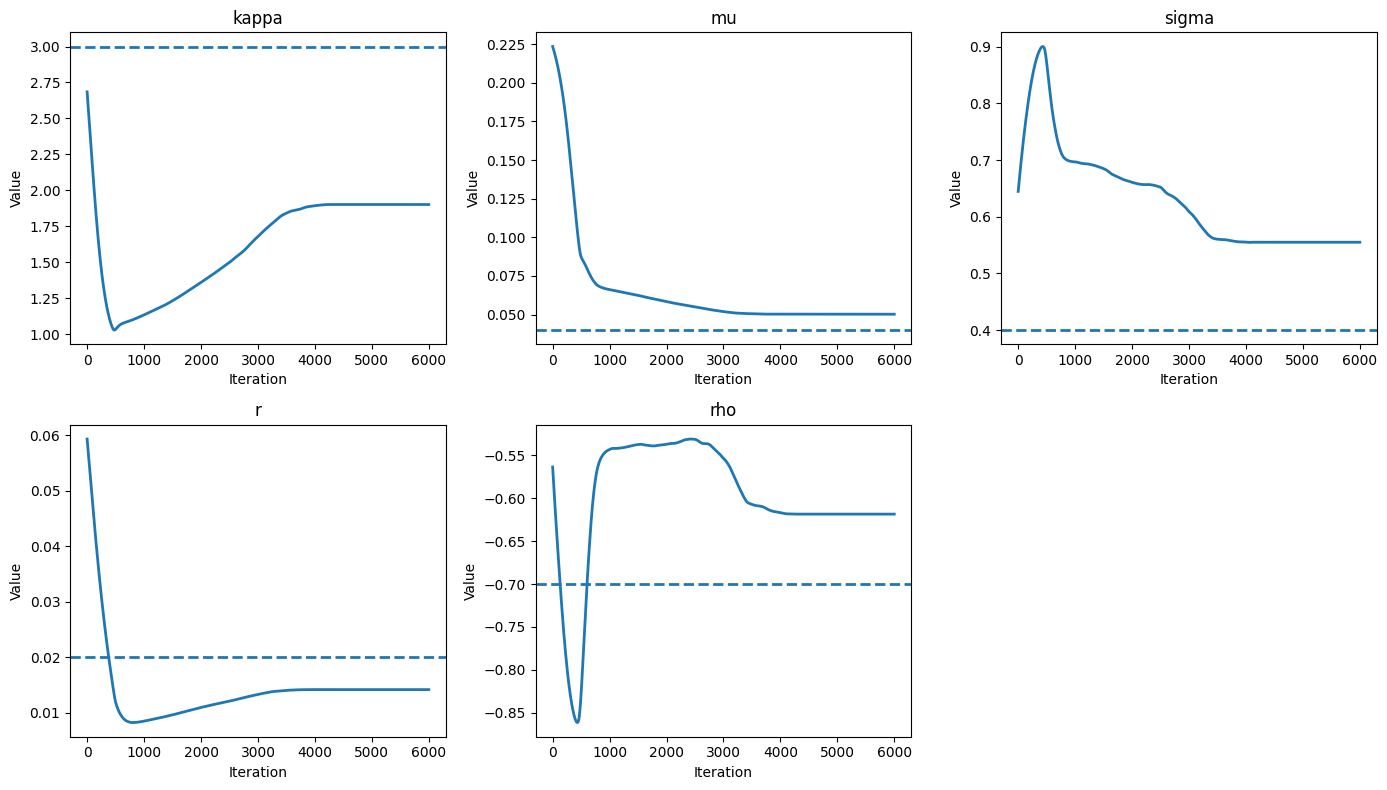

In [ ]:
param_history = best_run["param_history"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

names = ["kappa", "mu", "sigma", "r", "rho"]
true_vals = [
    true_params["kappa"],
    true_params["mu"],
    true_params["sigma"],
    true_params["r"],
    true_params["rho"]
]

for i, name in enumerate(names):
    axes[i].plot(param_history[:, i], linewidth=2)
    axes[i].axhline(true_vals[i], linestyle="--", linewidth=2)
    axes[i].set_title(name)
    axes[i].set_xlabel("Iteration")
    axes[i].set_ylabel("Value")
axes[5].axis("off")
plt.tight_layout()
plt.show()

Out-of-sample maturities: tensor([0.3500, 0.6500, 0.9500, 1.1500, 1.4000, 1.6000, 1.8500],
       device='cuda:0')
Out-of-sample strikes: tensor([ 62.5000,  67.5000,  72.5000,  77.5000,  82.5000,  87.5000,  92.5000,
         97.5000, 102.5000, 107.5000, 112.5000, 117.5000, 122.5000, 127.5000,
        132.5000], device='cuda:0')


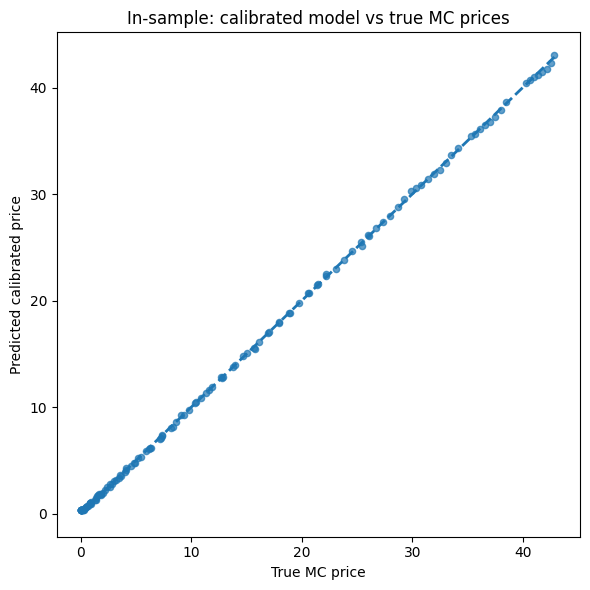

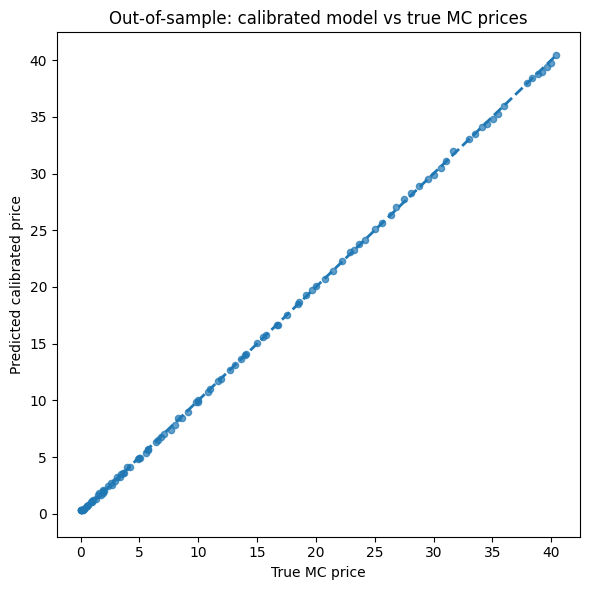


Surface fit summary:
         Dataset       MAE     RMSE  Mean Rel Error
0      In-sample  0.129539  0.16511       50.658386
1  Out-of-sample  0.107780  0.13650        1.945043


In [ ]:
@torch.no_grad()
def nn_price_surface(model, x_mean, x_std, X_surface):
    X_std = (X_surface - x_mean) / x_std
    pred = model(X_std).reshape(-1)
    return pred


def compute_surface_metrics(y_true, y_pred, rel_eps=1e-4):
    y_true_np = y_true.reshape(-1)
    y_pred_np = y_pred.reshape(-1)

    abs_err = np.abs(y_pred_np - y_true_np)
    rmse = np.sqrt(np.mean((y_pred_np - y_true_np) ** 2))
    mae = np.mean(abs_err)
    rel_err = np.mean(abs_err / (np.abs(y_true_np) + rel_eps))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Mean Rel Error": rel_err
    }


def plot_pred_vs_true_surface(y_true, y_pred, title="Predicted vs true prices"):
    y_true_np = y_true.reshape(-1)
    y_pred_np = y_pred.reshape(-1)

    mn = min(y_true_np.min(), y_pred_np.min())
    mx = max(y_true_np.max(), y_pred_np.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_np, y_pred_np, s=20, alpha=0.7)
    plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)
    plt.xlabel("True MC price")
    plt.ylabel("Predicted calibrated price")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# IN-SAMPLE EVALUATION calibrated surface = NN with calibrated params
X_surface_in = build_surface_inputs(
    S0=S0_star,
    Y0=Y0_star,
    kappa=kappa_cal,
    mu=mu_cal,
    sigma=sigma_cal,
    r=r_cal,
    rho=rho_cal,
    K_grid=K_grid,
    T_grid=T_grid,
    device=device
)

P_surface_cal_in = nn_price_surface(model, x_mean, x_std, X_surface_in)
P_surface_cal_in = P_surface_cal_in.view(len(T_grid), len(K_grid)).detach().cpu().numpy()
P_surface_true_in = P_surface_obs.detach().cpu().numpy()
metrics_in = compute_surface_metrics(P_surface_true_in, P_surface_cal_in)


# K and T NOT used in calibration
T_grid_test = torch.tensor(
    [0.35, 0.65, 0.95, 1.15, 1.40, 1.60, 1.85],
    dtype=torch.float32,
    device=device
)
K_grid_test = torch.tensor(
    [62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5,
     102.5, 107.5, 112.5, 117.5, 122.5, 127.5, 132.5],
    dtype=torch.float32,
    device=device
)

print("Out-of-sample maturities:", T_grid_test)
print("Out-of-sample strikes:", K_grid_test)


# TRUE OUT-OF-SAMPLE SURFACE BY MONTE CARLO using TRUE parameters, not calibrated ones
X_surface_test_true = build_surface_inputs(
    S0=S0_star,
    Y0=Y0_star,
    kappa=true_params["kappa"],
    mu=true_params["mu"],
    sigma=true_params["sigma"],
    r=true_params["r"],
    rho=true_params["rho"],
    K_grid=K_grid_test,
    T_grid=T_grid_test,
    device=device
)

MC_PATHS_TEST_SURFACE = 200_000
N_STEPS_TEST_SURFACE = 1000

P_surface_true_out = heston_mc_price_batch_av(
    X_surface_test_true,
    n_paths=MC_PATHS_TEST_SURFACE,
    n_steps=N_STEPS_TEST_SURFACE,
    device=device
)

P_surface_true_out = P_surface_true_out.view(len(T_grid_test), len(K_grid_test)).detach().cpu().numpy()


# CALIBRATED OUT-OF-SAMPLE SURFACE VIA THE NN using CALIBRATED parameters
X_surface_test_cal = build_surface_inputs(
    S0=S0_star,
    Y0=Y0_star,
    kappa=kappa_cal,
    mu=mu_cal,
    sigma=sigma_cal,
    r=r_cal,
    rho=rho_cal,
    K_grid=K_grid_test,
    T_grid=T_grid_test,
    device=device
)

P_surface_cal_out = nn_price_surface(model, x_mean, x_std, X_surface_test_cal)
P_surface_cal_out = P_surface_cal_out.view(len(T_grid_test), len(K_grid_test)).detach().cpu().numpy()
metrics_out = compute_surface_metrics(P_surface_true_out, P_surface_cal_out)

plot_pred_vs_true_surface(
    P_surface_true_in,
    P_surface_cal_in,
    title="In-sample: calibrated model vs true MC prices"
    )
plot_pred_vs_true_surface(
    P_surface_true_out,
    P_surface_cal_out,
    title="Out-of-sample: calibrated model vs true MC prices"
)


df_fit = pd.DataFrame([
    {"Dataset": "In-sample", **metrics_in},
    {"Dataset": "Out-of-sample", **metrics_out},
])

print("\nSurface fit summary:")
print(df_fit.round(6))

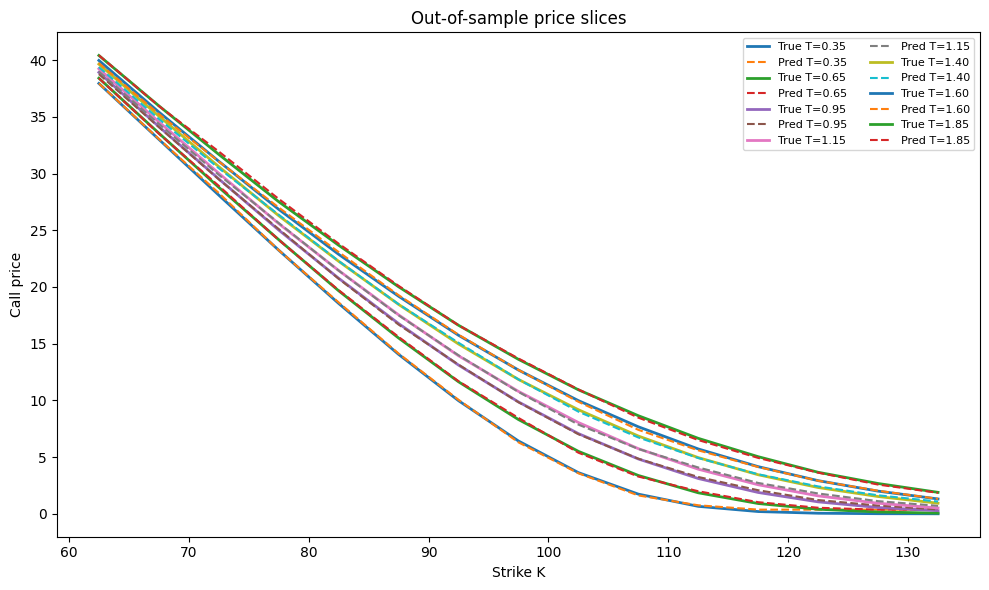

In [77]:
def plot_surface_slices(K_grid_np, T_grid_np, P_true, P_pred, title="Observed vs calibrated slices"):
    plt.figure(figsize=(10, 6))
    for i, T in enumerate(T_grid_np):
        plt.plot(K_grid_np, P_true[i], linewidth=2, label=f"True T={T:.2f}")
        plt.plot(K_grid_np, P_pred[i], linestyle="--", linewidth=1.5, label=f"Pred T={T:.2f}")

    plt.xlabel("Strike K")
    plt.ylabel("Call price")
    plt.title(title)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

plot_surface_slices(
    K_grid_test.detach().cpu().numpy(),
    T_grid_test.detach().cpu().numpy(),
    P_surface_true_out,
    P_surface_cal_out,
    title="Out-of-sample price slices"
)